In [ ]:
# This is part of the manuscript titled "Feedback-mediated circulation and persistence of stochastic fluctuations in gene regulatory circuits"

# Correspondence with the paper

# Please note 
# 1. The four TNF motifs : Double positive(++), Double negative(--), Negative positive(-+) and Positive negative(+-) motifs
# 2. alpha_x and alpha_y are production rates of X and Y
# 3. beta_x and beta_y are degradation rates of X and Y
# 4. delta is feedback strength given by kxy/kyx (here delta is a list of feedback strength values)
# 5. Txy and Tyx are time averaging factors
# 6. xav = < x >, yav = < y > 
# 7. stochastic simulation results averaged over n=100000 trajectories, tend is the end time of each simulated trajectory
# 8. G = H (feedback gain)
# 9. a1,a2,a3,a4 are the propensities and a0 is the total propensity
# 10. fxyp and fyxp are the derivatives of the production terms or the Hill functions 
# 11. timelag is a list of values of τ 
# 12. rhoxx0 and rhoyy0 are no-feedback autocorrelations where as rhoxx and rhoyy denote autocorrelations of X and Y in presence of feedback
# 13. xvar = variance of X; yvar = variance of Y and xycov= σxy^2
# 14. The data is exported and plotted 

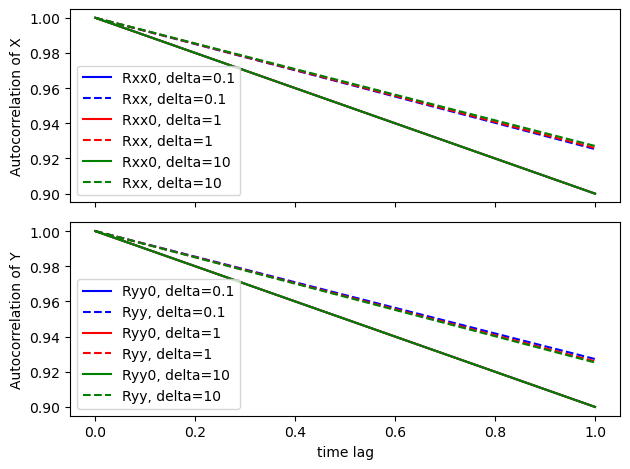

In [1]:
#double positive/ both activation
from numba import njit
import numpy as np
import matplotlib.pyplot as plt

tend = 2000
alpha_x = 10
alpha_y = 10
beta_x = 0.1
beta_y = 0.1
delta = [0.1, 1, 10]
timelag = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
n = 100000

@njit
def gillespie(tend, alpha_x, alpha_y, beta_x, beta_y, kxy, kyx):
    x, y, t = 50, 50, 0.0     #initial condition
    while t < tend:
        a1 = (alpha_x * y) / (kyx + y)
        a2 = beta_x * x
        a3 = (alpha_y * x) / (kxy + x)
        a4 = beta_y * y
        a0 = a1 + a2 + a3 + a4
        if a0 == 0:
            break
        r1 = np.random.random()
        r2 = np.random.random()
        t = t + (1/a0)*np.log(1/r1) #update time
        if r2 * a0 < a1:
            x += 1
        elif r2 * a0 < (a1 + a2):
            x -= 1
        elif r2 * a0 < (a1 + a2 + a3):
            y += 1
        elif r2*a0 < (a1 + a2 + a3 + a4):
            y -= 1
    return x, y

rho_xx  = [[] for m in range(3)]
rho_yy  = [[] for m in range(3)]
rho_xx0 = [[] for m in range(3)]
rho_yy0 = [[] for m in range(3)]
j = 0
for d in delta:
    kxy = 50 * (np.sqrt(d))
    kyx = 50 / (np.sqrt(d))

    x_last = []
    y_last = []

    for i in range(n):
        x, y = gillespie(tend, alpha_x, alpha_y, beta_x, beta_y, kxy, kyx)
        x_last.append(x)
        y_last.append(y)

    xav = np.mean(x_last)
    yav = np.mean(y_last)
    
    #Derivatives
    fxyp = (alpha_x * kyx) / ((yav + kyx) ** 2)
    fyxp = (alpha_y * kxy) / ((xav + kxy) ** 2)
    
    xvar = np.var(x_last)
    yvar = np.var(y_last)
    #ddof=1 for sample covariance (divides by n-1,standard for finite samples) & ddof=0 for population covariance (divides by n, use if n is very large)
    xycov_matrix = np.cov(x_last, y_last, ddof=0)
    xycov = xycov_matrix[0,1]                    #[0,1] or [1,0] gives the covariance, [0,0] gives var(x), [1,1] gives var(y)

    for tl in timelag:
        rhoxx0 = 1 - (beta_x*tl)
        rho_xx0[j].append(rhoxx0)
        rhoxx = 1 - (beta_x*tl) + fxyp*tl*(xycov/xvar)
        rho_xx[j].append(rhoxx)
        
        rhoyy0 = 1 - (beta_y*tl)
        rho_yy0[j].append(rhoyy0)
        rhoyy = 1 - (beta_y*tl) + fyxp*tl*(xycov/yvar)
        rho_yy[j].append(rhoyy)
    j=j+1  

f, (ax1,ax2) = plt.subplots(2, sharex=True, sharey=False)

colors = ['blue', 'red', 'green']
delta_labels = [0.1, 1, 10]

for k in range(3):
    ax1.plot(timelag, rho_xx0[k], color=colors[k], label=f"Rxx0, delta={delta_labels[k]}")
    ax1.plot(timelag, rho_xx[k],  color=colors[k], linestyle='--', label=f"Rxx, delta={delta_labels[k]}")

for k in range(3):
    ax2.plot(timelag, rho_yy0[k], color=colors[k], label=f"Ryy0, delta={delta_labels[k]}")
    ax2.plot(timelag, rho_yy[k],  color=colors[k], linestyle='--', label=f"Ryy, delta={delta_labels[k]}")

ax1.set_ylabel("Autocorrelation of X")
ax2.set_ylabel("Autocorrelation of Y")
ax2.set_xlabel("time lag")
ax1.legend(loc="lower left")
ax2.legend(loc="lower left")

np.savetxt('DP_autoxx_new.dat', np.column_stack((timelag, rho_xx0[0], rho_xx[0], rho_xx0[1], rho_xx[1], rho_xx0[2], rho_xx[2])), comments='', fmt="%.6f", delimiter="\t")
np.savetxt('DP_autoyy_new.dat', np.column_stack((timelag, rho_yy0[0], rho_yy[0], rho_yy0[1], rho_yy[1], rho_yy0[2], rho_yy[2])), comments='', fmt="%.6f", delimiter="\t")

plt.tight_layout()
plt.show()

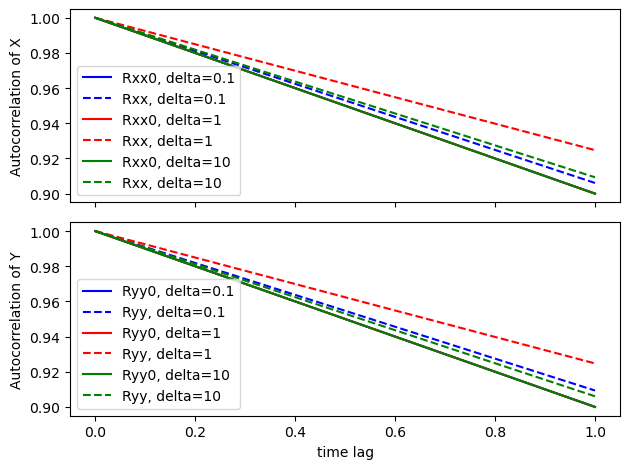

In [2]:
#double negative/ both repression

from numba import njit
import numpy as np
import matplotlib.pyplot as plt

tend = 2000
alpha_x = 10
alpha_y = 10
beta_x = 0.1
beta_y = 0.1
delta = [0.1, 1, 10]
timelag = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
n = 100000

@njit
def gillespie(tend, alpha_x, alpha_y, beta_x, beta_y, kxy, kyx):
    x, y, t = 50, 50, 0.0     #initial condition
    while t < tend:
        a1 = (alpha_x * kyx) / (kyx + y)
        a2 = beta_x * x
        a3 = (alpha_y * kxy) / (kxy + x)
        a4 = beta_y * y
        a0 = a1 + a2 + a3 + a4
        if a0 == 0:
            break
        r1 = np.random.random()
        r2 = np.random.random()
        t = t + (1/a0)*np.log(1/r1) #update time
        if r2 * a0 < a1:
            x += 1
        elif r2 * a0 < (a1 + a2):
            x -= 1
        elif r2 * a0 < (a1 + a2 + a3):
            y += 1
        elif r2*a0 < (a1 + a2 + a3 + a4):
            y -= 1
    return x, y

rho_xx  = [[] for m in range(3)]
rho_yy  = [[] for m in range(3)]
rho_xx0 = [[] for m in range(3)]
rho_yy0 = [[] for m in range(3)]
j = 0
for d in delta:
    kxy = 50 * (np.sqrt(d))
    kyx = 50 / (np.sqrt(d))

    x_last = []
    y_last = []

    for i in range(n):
        x, y = gillespie(tend, alpha_x, alpha_y, beta_x, beta_y, kxy, kyx)
        x_last.append(x)
        y_last.append(y)

    xav = np.mean(x_last)
    yav = np.mean(y_last)
    
    #Derivatives
    fxyp = (-alpha_x * kyx) / ((yav + kyx) ** 2)
    fyxp = (-alpha_y * kxy) / ((xav + kxy) ** 2)
    
    xvar = np.var(x_last)
    yvar = np.var(y_last)
    #ddof=1 for sample covariance (divides by n-1,standard for finite samples) & ddof=0 for population covariance (divides by n, use if n is very large)
    xycov_matrix = np.cov(x_last, y_last, ddof=0)
    xycov = xycov_matrix[0, 1]                    #[0,1] or [1,0] gives the covariance, [0,0] gives var(x), [1,1] gives var(y)

    for tl in timelag:
        rhoxx0 = 1 - (beta_x*tl)
        rho_xx0[j].append(rhoxx0)
        rhoxx = 1 - (beta_x*tl) + (fxyp*tl*(xycov/xvar))
        rho_xx[j].append(rhoxx)
        
        rhoyy0 = 1 - (beta_y*tl)
        rho_yy0[j].append(rhoyy0)
        rhoyy = 1 - (beta_y*tl) + (fyxp*tl*(xycov/yvar))
        rho_yy[j].append(rhoyy)
    j=j+1  

f, (ax1, ax2) = plt.subplots(2, sharex=True, sharey=False)

colors = ['blue', 'red', 'green']
delta_labels = [0.1, 1, 10]

for k in range(3):
    ax1.plot(timelag, rho_xx0[k], color=colors[k], label=f"Rxx0, delta={delta_labels[k]}")
    ax1.plot(timelag, rho_xx[k],  color=colors[k], linestyle='--', label=f"Rxx, delta={delta_labels[k]}")

for k in range(3):
    ax2.plot(timelag, rho_yy0[k], color=colors[k], label=f"Ryy0, delta={delta_labels[k]}")
    ax2.plot(timelag, rho_yy[k],  color=colors[k], linestyle='--', label=f"Ryy, delta={delta_labels[k]}")

ax1.set_ylabel("Autocorrelation of X")
ax2.set_ylabel("Autocorrelation of Y")
ax2.set_xlabel("time lag")
ax1.legend(loc="lower left")
ax2.legend(loc="lower left")

np.savetxt('DN_autoxx_new.dat', np.column_stack((timelag, rho_xx0[0], rho_xx[0], rho_xx0[1], rho_xx[1], rho_xx0[2], rho_xx[2])), comments='', fmt="%.6f", delimiter="\t")
np.savetxt('DN_autoyy_new.dat', np.column_stack((timelag, rho_yy0[0], rho_yy[0], rho_yy0[1], rho_yy[1], rho_yy0[2], rho_yy[2])), comments='', fmt="%.6f", delimiter="\t")

plt.tight_layout()
plt.show()

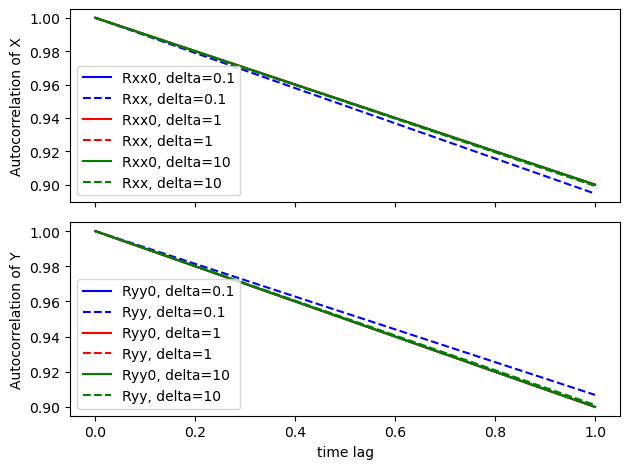

In [3]:
#negative positive/ x represses y, y activates x

from numba import njit
import numpy as np
import matplotlib.pyplot as plt

tend = 2000
alpha_x = 10
alpha_y = 10
beta_x = 0.1
beta_y = 0.1
delta = [0.1, 1, 10]
timelag = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
n = 100000

@njit
def gillespie(tend, alpha_x, alpha_y, beta_x, beta_y, kxy, kyx):
    x, y, t = 50, 50, 0.0     #initial condition
    while t < tend:
        a1 = (alpha_x * y) / (kyx + y)
        a2 = beta_x * x
        a3 = (alpha_y * kxy) / (kxy + x)
        a4 = beta_y * y
        a0 = a1 + a2 + a3 + a4
        if a0 == 0:
            break
        r1 = np.random.random()
        r2 = np.random.random()
        t = t + (1/a0)*np.log(1/r1) #update time
        if r2 * a0 < a1:
            x += 1
        elif r2 * a0 < (a1 + a2):
            x -= 1
        elif r2 * a0 < (a1 + a2 + a3):
            y += 1
        elif r2*a0 < (a1 + a2 + a3 + a4):
            y -= 1
    return x, y

rho_xx  = [[] for m in range(3)]
rho_yy  = [[] for m in range(3)]
rho_xx0 = [[] for m in range(3)]
rho_yy0 = [[] for m in range(3)]
j = 0
for d in delta:
    kxy = 50 * (np.sqrt(d))
    kyx = 50 / (np.sqrt(d))

    x_last = []
    y_last = []

    for i in range(n):
        x, y = gillespie(tend, alpha_x, alpha_y, beta_x, beta_y, kxy, kyx)
        x_last.append(x)
        y_last.append(y)

    xav = np.mean(x_last)
    yav = np.mean(y_last)
    
    #Derivatives
    fxyp = (alpha_x * kyx) / ((yav + kyx) ** 2)
    fyxp = (-alpha_y * kxy) / ((xav + kxy) ** 2)
    
    xvar = np.var(x_last)
    yvar = np.var(y_last)
    #ddof=1 for sample covariance (divides by n-1,standard for finite samples) & ddof=0 for population covariance (divides by n, use if n is very large)
    xycov_matrix = np.cov(x_last, y_last, ddof=0)
    xycov = xycov_matrix[0, 1]                    #[0,1] or [1,0] gives the covariance, [0,0] gives var(x), [1,1] gives var(y)

    for tl in timelag:
        rhoxx0 = 1 - (beta_x*tl)
        rho_xx0[j].append(rhoxx0)
        rhoxx = 1 - (beta_x*tl) + fxyp*tl*(xycov/xvar)
        rho_xx[j].append(rhoxx)
        
        rhoyy0 = 1 - (beta_y*tl)
        rho_yy0[j].append(rhoyy0)
        rhoyy = 1 - (beta_y*tl) + fyxp*tl*(xycov/yvar)
        rho_yy[j].append(rhoyy)
    j=j+1  

f, (ax1, ax2) = plt.subplots(2, sharex=True, sharey=False)

colors = ['blue', 'red', 'green']
delta_labels = [0.1, 1, 10]

for k in range(3):
    ax1.plot(timelag, rho_xx0[k], color=colors[k], label=f"Rxx0, delta={delta_labels[k]}")
    ax1.plot(timelag, rho_xx[k],  color=colors[k], linestyle='--', label=f"Rxx, delta={delta_labels[k]}")

for k in range(3):
    ax2.plot(timelag, rho_yy0[k], color=colors[k], label=f"Ryy0, delta={delta_labels[k]}")
    ax2.plot(timelag, rho_yy[k],  color=colors[k], linestyle='--', label=f"Ryy, delta={delta_labels[k]}")

ax1.set_ylabel("Autocorrelation of X")
ax2.set_ylabel("Autocorrelation of Y")
ax2.set_xlabel("time lag")
ax1.legend(loc="lower left")
ax2.legend(loc="lower left")

np.savetxt('NP_autoxx_new.dat', np.column_stack((timelag, rho_xx0[0], rho_xx[0], rho_xx0[1], rho_xx[1], rho_xx0[2], rho_xx[2])), comments='', fmt="%.6f", delimiter="\t")
np.savetxt('NP_autoyy_new.dat', np.column_stack((timelag, rho_yy0[0], rho_yy[0], rho_yy0[1], rho_yy[1], rho_yy0[2], rho_yy[2])), comments='', fmt="%.6f", delimiter="\t")

plt.tight_layout()
plt.show()

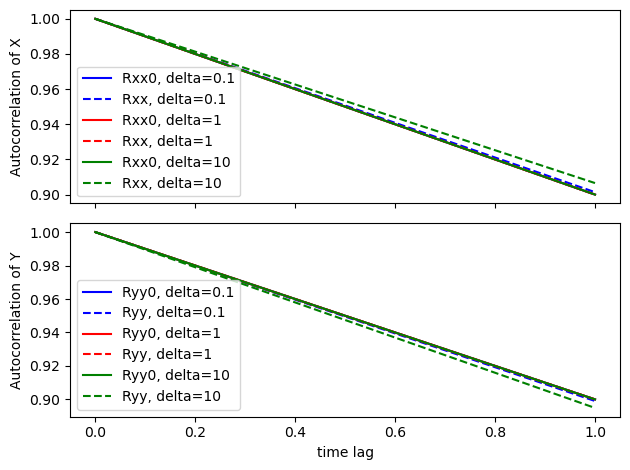

In [4]:
#positive negative/ x represses y, y activates x

from numba import njit
import numpy as np
import matplotlib.pyplot as plt

tend = 2000
alpha_x = 10
alpha_y = 10
beta_x = 0.1
beta_y = 0.1
delta = [0.1, 1, 10]
timelag = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
n = 100000

@njit
def gillespie(tend, alpha_x, alpha_y, beta_x, beta_y, kxy, kyx):
    x, y, t = 50, 50, 0.0     #initial condition
    while t < tend:
        a1 = (alpha_x * kyx) / (kyx + y)
        a2 = beta_x * x
        a3 = (alpha_y * x) / (kxy + x)
        a4 = beta_y * y
        a0 = a1 + a2 + a3 + a4
        if a0 == 0:
            break
        r1 = np.random.random()
        r2 = np.random.random()
        t = t + (1/a0)*np.log(1/r1) #update time
        if r2 * a0 < a1:
            x += 1
        elif r2 * a0 < (a1 + a2):
            x -= 1
        elif r2 * a0 < (a1 + a2 + a3):
            y += 1
        elif r2*a0 < (a1 + a2 + a3 + a4):
            y -= 1
    return x, y

rho_xx  = [[] for m in range(3)]
rho_yy  = [[] for m in range(3)]
rho_xx0 = [[] for m in range(3)]
rho_yy0 = [[] for m in range(3)]
j = 0
for d in delta:
    kxy = 50 * (np.sqrt(d))
    kyx = 50 / (np.sqrt(d))

    x_last = []
    y_last = []

    for i in range(n):
        x, y = gillespie(tend, alpha_x, alpha_y, beta_x, beta_y, kxy, kyx)
        x_last.append(x)
        y_last.append(y)

    xav = np.mean(x_last)
    yav = np.mean(y_last)
    
    #Derivatives
    fxyp = (-alpha_x * kyx) / ((yav + kyx) ** 2)
    fyxp = (alpha_y * kxy) / ((xav + kxy) ** 2)
    
    xvar = np.var(x_last)
    yvar = np.var(y_last)
    #ddof=1 for sample covariance (divides by n-1,standard for finite samples) & ddof=0 for population covariance (divides by n, use if n is very large)
    xycov_matrix = np.cov(x_last, y_last, ddof=0)
    xycov = xycov_matrix[0, 1]                    #[0,1] or [1,0] gives the covariance, [0,0] gives var(x), [1,1] gives var(y)

    for tl in timelag:
        rhoxx0 = 1 - (beta_x*tl)
        rho_xx0[j].append(rhoxx0)
        rhoxx = 1 - (beta_x*tl) + fxyp*tl*(xycov/xvar)
        rho_xx[j].append(rhoxx)
        
        rhoyy0 = 1 - (beta_y*tl)
        rho_yy0[j].append(rhoyy0)
        rhoyy = 1 - (beta_y*tl) + fyxp*tl*(xycov/yvar)
        rho_yy[j].append(rhoyy)
    j=j+1  

f, (ax1, ax2) = plt.subplots(2, sharex=True, sharey=False)

colors = ['blue', 'red', 'green']
delta_labels = [0.1, 1, 10]

for k in range(3):
    ax1.plot(timelag, rho_xx0[k], color=colors[k], label=f"Rxx0, delta={delta_labels[k]}")
    ax1.plot(timelag, rho_xx[k],  color=colors[k], linestyle='--', label=f"Rxx, delta={delta_labels[k]}")

for k in range(3):
    ax2.plot(timelag, rho_yy0[k], color=colors[k], label=f"Ryy0, delta={delta_labels[k]}")
    ax2.plot(timelag, rho_yy[k],  color=colors[k], linestyle='--', label=f"Ryy, delta={delta_labels[k]}")

ax1.set_ylabel("Autocorrelation of X")
ax2.set_ylabel("Autocorrelation of Y")
ax2.set_xlabel("time lag")
ax1.legend(loc="lower left")
ax2.legend(loc="lower left")

np.savetxt('PN_autoxx_new.dat', np.column_stack((timelag, rho_xx0[0], rho_xx[0], rho_xx0[1], rho_xx[1], rho_xx0[2], rho_xx[2])), comments='', fmt="%.6f", delimiter="\t")
np.savetxt('PN_autoyy_new.dat', np.column_stack((timelag, rho_yy0[0], rho_yy[0], rho_yy0[1], rho_yy[1], rho_yy0[2], rho_yy[2])), comments='', fmt="%.6f", delimiter="\t")

plt.tight_layout()
plt.show()